In [2]:
# importing library
import osmnx as ox

import pandas as pd
import folium
from folium import DivIcon
import requests

In [3]:
place = "Metro Manila, Philippines"

In [4]:
highway_types = ["primary", "secondary", "primary_link", "secondary_link"]

In [5]:
graph = ox.graph_from_place(
    place,
    network_type="all",
    custom_filter='["highway"~"{}"]'.format("|".join(highway_types)),
)

In [6]:
type(graph)

networkx.classes.multidigraph.MultiDiGraph

<strong>The result in previous is networkx class and now it need to be converted in geopandas for further process of data</strong>

In [7]:
nodes, streets = ox.graph_to_gdfs(graph)

In [8]:
# printing streets data
streets.head()


# It is converted to the form of pandas data frame with a capability for geographic data handling

osmid  \
u        v          key                                                      
12067308 24798154   0    [224039651, 224039654, 224039655, 1059061389, ...   
12067395 990043712  0                                  [2667099, 85396158]   
         1934653694 0                                            675183383   
12067407 316549463  0                               [1035321072, 13867004]   
         12067409   0                                            709075245   

                           highway   lanes maxspeed                     name  \
u        v          key                                                        
12067308 24798154   0    secondary  [4, 2]       40    F. B. Harrison Street   
12067395 990043712  0      primary       2       60             Lerma Street   
         1934653694 0    secondary       3       40        Mendoza Boulevard   
12067407 316549463  0    secondary       2      NaN  E. Rodriguez Sr. Avenue   
         12067409   0      primary       4       60          Mabuhay Rotonda   

                          width  oneway reversed      length  \
u        v          key                                        
12067308 24798154   0    [9, 8]   False     True  940.541201   
12067395 990043712  0       NaN    True    False  224.607769   
         1934653694 0       NaN    True    False  177.451214   
12067407 316549463  0       NaN    True    False   86.164746   
         12067409   0      14.4    True    False   19.521193   

                                                                  geometry  \
u        v          key                                                      
12067308 24798154   0    LINESTRING (120.99573 14.53787, 120.99572 14.5...   
12067395 990043712  0    LINESTRING (120.98539 14.6046, 120.98545 14.60...   
         1934653694 0    LINESTRING (120.98539 14.6046, 120.98567 14.60...   
12067407 316549463  0    LINESTRING (121.00184 14.61765, 121.00195 14.6...   
         12067409   0    LINESTRING (121.00184 14.61765, 121.00186 14.6...   

                         ref    junction access bridge tunnel  
u        v          key                                        
12067308 24798154   0    NaN         NaN    NaN    NaN    NaN  
12067395 990043712  0    170         NaN    NaN    NaN    NaN  
         1934653694 0    NaN         NaN    NaN    NaN    NaN  
12067407 316549463  0    NaN         NaN    NaN    NaN    NaN  
         12067409   0    170  roundabout    NaN    NaN    NaN

In [9]:
# printing nodes data
nodes.head()

,y,x,street_count,highway,junction,geometry
osmid,,,,,,
12067308,14.537867,120.995733,1,NaN,NaN,POINT (120.99573 14.53787)
12067395,14.604596,120.985385,3,motorway_junction,NaN,POINT (120.98539 14.6046)
12067407,14.617651,121.001841,3,NaN,NaN,POINT (121.00184 14.61765)
12067409,14.617816,121.001881,3,NaN,NaN,POINT (121.00188 14.61782)
12067411,14.617969,121.001701,3,NaN,NaN,POINT (121.0017 14.61797)


In [10]:
# checking all the keys inside the data
streets.keys()

Index(['osmid', 'highway', 'lanes', 'maxspeed', 'name', 'width', 'oneway',
       'reversed', 'length', 'geometry', 'ref', 'junction', 'access', 'bridge',
       'tunnel'],
      dtype='str')

In [11]:
# printing data from a single key name
streets["highway"]

u            v            key
12067308     24798154     0           secondary
12067395     990043712    0             primary
             1934653694   0           secondary
12067407     316549463    0           secondary
             12067409     0             primary
                                      ...      
13710396927  243433666    0           secondary
13712974484  248836584    0      secondary_link
13961199621  61091666     0           secondary
             13961199625  0      secondary_link
13961199625  11954284569  0           secondary
Name: highway, Length: 5011, dtype: object

<Axes: >

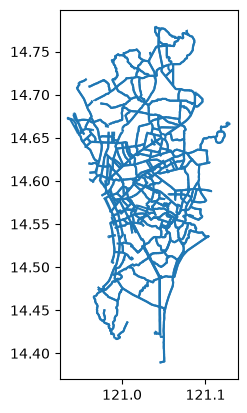

In [12]:
streets.plot()

In [13]:
# styling the road network
style = {'color': '#9EBCDA', "opacity": "0.85", 'weight':'1'}

In [14]:

# manual adding marker location to dataframe
marker_loc = pd.DataFrame({"lon": [14.445049],
                          "lat": [120.999312],
                          "name": ["Sonora Garden Residences"],
                          "value": [100]}
)

marker_loc


# Las Piñas, Makati, Pasig, Baguio, Batangas

,lon,lat,name,value
0,14.445049,120.999312,Sonora Garden Residences,100


In [15]:

#query = """
#[out:json];
#node(944192784);
#out;
#"""

#response = requests.post(
#    "https://overpass-api.de/api",
#    data={"data": query},
#    timeout=60,
#)

#print(response.status_code)
#print(response.text[:500])

In [16]:
ox.settings.overpass_url

'https://overpass-api.de/api'

In [17]:
# manual selection of the locations and turning them into data frame
locations = pd.DataFrame ([
    {"type": "relation", "id": 688289370, "name": "Allegra Garden Place", "lat": 14.563527, "lon": 121.067120},
    {"type": "relation", "id": 1329828415, "name": "Prisma Residences", "lat": 14.563997, "lon": 121.067850},
    {"type": "relation", "id": 20297190, "name": "Fortis Residence ", "lat": 14.542444, "lon": 121.016786},
    {"type": "relation", "id": 18167226, "name": "Sonora Garden Residences", "lat": 14.444956, "lon": 120.999234}
])

locations

,type,id,name,lat,lon
0,relation,688289370,Allegra Garden Place,14.563527,121.067120
1,relation,1329828415,Prisma Residences,14.563997,121.067850
2,relation,20297190,Fortis Residence,14.542444,121.016786
3,relation,18167226,Sonora Garden Residences,14.444956,120.999234


In [18]:
# printing to check items from locations
for n, loc in locations.items():
    print(n, loc)

type 0    relation
1    relation
2    relation
3    relation
Name: type, dtype: str
id 0     688289370
1    1329828415
2      20297190
3      18167226
Name: id, dtype: int64
name 0        Allegra Garden Place
1           Prisma Residences
2           Fortis Residence 
3    Sonora Garden Residences
Name: name, dtype: str
lat 0    14.563527
1    14.563997
2    14.542444
3    14.444956
Name: lat, dtype: float64
lon 0    121.067120
1    121.067850
2    121.016786
3    120.999234
Name: lon, dtype: float64


In [19]:
# making empty list
relation_id = []

# looping through locations to place IDs to the list
for id in locations["id"]:
    relation_id.append(id)

relation_id

[688289370, 1329828415, 20297190, 18167226]

In [20]:
#lat = locations["lat"]
#lon = locations["lon"]


    #icon=folium.Icon(icon="home", color="green"), # adding marker in shape of home
son = locations["name"]
son

son[3]

'Sonora Garden Residences'

In [27]:
# base map folium with some style
m = folium.Map(
    [14.5723, 121.0364],
    zoom_start=12,
    tiles="CartoDB Positron"
)

# adding road network on top of map
roads = folium.GeoJson(streets, style_function=lambda x: style).add_to(m)

for i in range(0, len(locations)):
    folium.Marker(
    location=[locations.iloc[i]["lat"], locations.iloc[i]["lon"]],
    popup=locations.iloc[i]["name"],
).add_to(m)

m

In [22]:
sonora = locations["name"]

s_list = []
s_list.append(sonora[3])

s_list

['Sonora Garden Residences']